In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [4]:
adult = pd.read_csv("../data/adult.csv")
adult.drop(["Unnamed: 0"], axis=1, inplace=True)
adult = adult[~adult.isin(["?"]).any(axis=1)]

invalid_salary = adult[
    ((adult["salary"] == "<=50K") & (adult["salary K$"] > 50)) |
    ((adult["salary"] == ">50K") & (adult["salary K$"] <= 50))
]

invalid_salary

,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$


# Task 1
Print the count of men and women in the dataset.

In [54]:
gender_count = adult["sex"].value_counts()

men = gender_count.get("Male")
women = gender_count.get("Female")

men, women

(np.int64(20380), np.int64(9782))

# Task 2
Find the average age of men in dataset

In [62]:
average_age_men = adult[adult["sex"] == "Male"]["age"].mean()
average_age_men

np.float64(39.18400392541707)

# Task 3
Get the percentage of people from Poland (native-country)

In [80]:
people_from_poland = adult[adult["native-country"] == "Poland"].shape[0]
total_people = adult.shape[0]

percentage_poland = (people_from_poland / total_people) * 100
percentage_poland

0.18566408063125786

# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [103]:
over_50_std = adult[adult["salary K$"] > 50]["age"].std()
over_50_mean = adult[adult["salary K$"] > 50]["age"].mean()

less_50_std = adult[adult["salary K$"] <= 50]["age"].std()
less_50_mean = adult[adult["salary K$"] <= 50]["age"].mean()


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [64]:
higher_education_mask = (
    (adult["education"] == "Bachelors") |
    (adult["education"] == "Prof-school") |
    (adult["education"] == "Assoc-acdm") |
    (adult["education"] == "Assoc-voc") |
    (adult["education"] == "Masters") |
    (adult["education"] == "Doctorate")
)

no_higher_education = adult[~higher_education_mask]

rich_no_higher_education = no_higher_education[
    no_higher_education["salary K$"] > 50
]

rich_no_higher_education.shape[0]

3178

# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [55]:
age_stats_education = adult.groupby("education")["age"].describe()
age_stats_education

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
10th,820.0,37.897561,16.225795,17.0,23.0,36.0,52.0,90.0
11th,1048.0,32.363550,15.089307,17.0,18.0,28.5,43.0,90.0
12th,377.0,32.013263,14.373710,17.0,19.0,28.0,41.0,79.0
1st-4th,151.0,44.622517,14.929051,19.0,33.0,44.0,56.0,81.0
5th-6th,288.0,41.649306,14.754622,17.0,28.0,41.0,53.0,82.0
7th-8th,557.0,47.631957,15.737479,17.0,34.0,49.0,60.0,90.0
9th,455.0,40.303297,15.335754,17.0,28.0,38.0,53.0,90.0
Assoc-acdm,1008.0,37.286706,10.509755,19.0,29.0,36.0,44.0,90.0
Assoc-voc,1307.0,38.246366,11.181253,19.0,30.0,37.0,45.0,84.0


# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [25]:
men = adult[adult["sex"] == "Male"]

married_men = men[men["marital-status"].str.startswith("Married")]
not_married_men = men[~men["marital-status"].str.startswith("Married")]

married_rich_percent = (
    married_men[married_men["salary K$"] > 50].shape[0]
    / married_men.shape[0]
) * 100

not_married_rich_percent = (
    not_married_men[not_married_men["salary K$"] > 50].shape[0]
    / not_married_men.shape[0]
) * 100

# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [31]:
max_hours = adult["hours-per-week"].max()

people_with_max_hours = adult[adult["hours-per-week"] == max_hours].shape[0]

# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

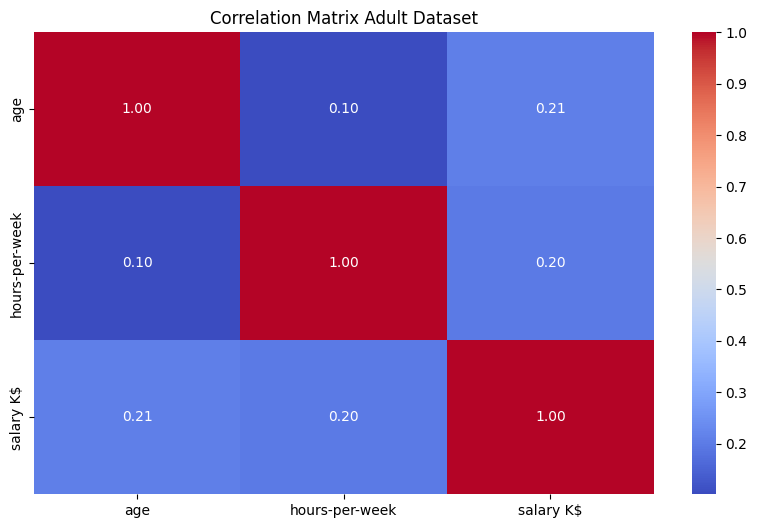

,age,salary K$
age,NaN,0.208203
salary K$,0.208203,NaN


In [50]:
df = adult.select_dtypes(include=["float64", "int64"])
df.head()

corr_matrix = df.corr()

plt.figure(figsize = (10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix Adult Dataset")
plt.show()


strong_corr = corr_matrix[
    (corr_matrix.abs() > 0.2) & (corr_matrix.abs() < 1)
]

strong_corr.dropna(how="all").dropna(axis=1, how="all")